In [109]:
import pyreadr

# Load the rds file
result = pyreadr.read_r('06_Cb_BTM_table.rds')

# pyreadr returns a dictionary; the data is usually under the 'None' key 
# because rds files contain a single object without a specific name.
df = result[None]


def get_patient(patient_n, clock_rank=0):
    var = df[df["best_K"] > clock_rank]
    sample_id = var["sample_id"].unique()[patient_n]
    return var[var["sample_id"] == sample_id]["sample_id"].iloc[0]


In [110]:
# Select a patient

# Load the rds file
result = pyreadr.read_r('06_Cb_BTM_table.rds')

# pyreadr returns a dictionary; the data is usually under the 'None' key 
# because rds files contain a single object without a specific name.
df = result[None]

patient_id = get_patient(13,clock_rank=1)

df = df[df["sample_id"] == patient_id]

print("Rows : " , df.shape[0])
print("Best K :",df["best_K"].unique())

Rows :  24
Best K : [2.]


In [111]:
# import dictionary for graph
from collections import defaultdict

# for permutations
from itertools import product

# Just make the df with only worth keep
gen_clk = df[["clock_rank","gene"]]

graph = defaultdict(int)

# Preprocessing
bhu = gen_clk.groupby("gene")["clock_rank"].min()

# Take only the first time genes appear in the clock_rank
for gene in bhu.index:
    min_clk = bhu[gene]
    df = df[~((df["gene"] == gene) & (df["clock_rank"] > min_clk))]


for i in range(df["clock_rank"].nunique()-1):
    df1 = df[df["clock_rank"] == i+1]
    df2 = df[df["clock_rank"] == i+2]
    for g1, g2 in product(df1["gene"].unique(), df2["gene"].unique()):
        graph[(i+1,g1, g2)] += 1

# Create a tree


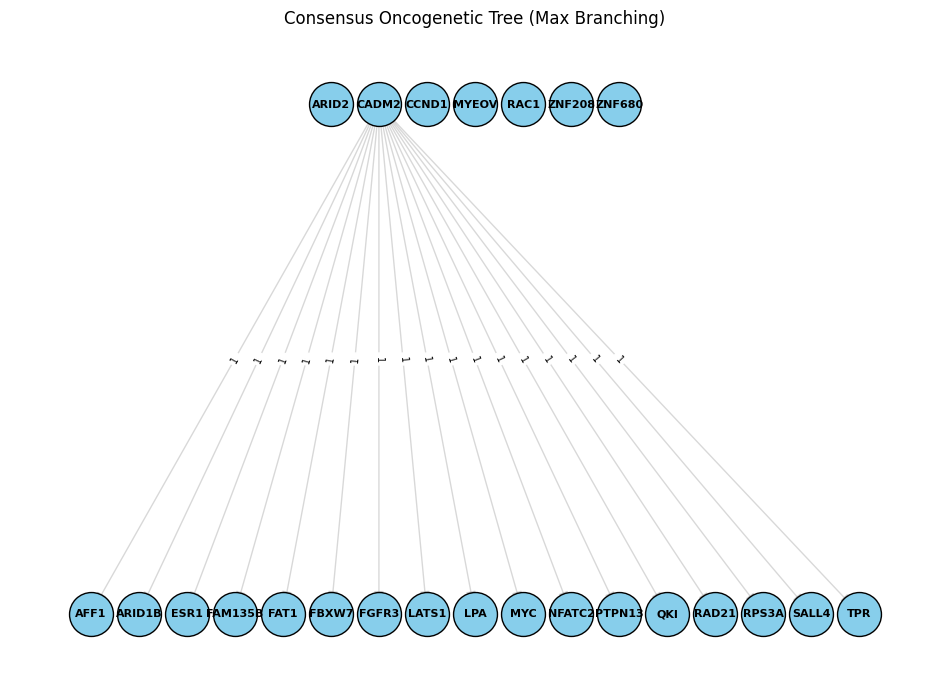

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. Build the Directed Graph from your dict: (rank, parent, child)
G = nx.DiGraph()
for (rank, g1, g2), weight in graph.items():
    G.add_edge(g1, g2, weight=weight)

# 2. Extract the Maximum Branching (The fix for your AttributeError)
# This algorithm finds the forest/tree that maximizes total weight
tree = nx.maximum_branching(G, attr='weight', default=0)

# 3. Layout logic: Ordered by clock_rank
node_ranks = df.set_index('gene')['clock_rank'].to_dict()
pos = {}

# Pre-calculate counts per rank to center the nodes
rank_groups = defaultdict(list)
for node in tree.nodes():
    rank_groups[node_ranks.get(node, 0)].append(node)

for rank, nodes in rank_groups.items():
    # Sort nodes alphabetically so the layout is stable
    nodes.sort()
    num_nodes = len(nodes)
    for i, node in enumerate(nodes):
        # Center nodes: (index - midpoint)
        x = i - (num_nodes - 1) / 2.0
        y = -rank  # Vertical flow
        pos[node] = (x, y)

# 4. Visualization
plt.figure(figsize=(12, 8))

# Draw edges and nodes
nx.draw_networkx_edges(tree, pos, alpha=0.3, edge_color="gray", arrows=True, arrowsize=15)
nx.draw_networkx_nodes(tree, pos, node_size=1000, node_color="skyblue", edgecolors="black")
nx.draw_networkx_labels(tree, pos, font_size=8, font_weight="bold")

# Add the patient counts (weights) on the edges
edge_labels = nx.get_edge_attributes(tree, 'weight')
nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size=7)

plt.title("Consensus Oncogenetic Tree (Max Branching)", pad=20)
plt.axis('off')
plt.show()
